## Assignment 2: Unsupervised Learning

Welcome to the second assignment of CS 541! In Assignment 1 there was always a label to fit. Here we take the labels away, and the two hard problems of unsupervised learning show up immediately: choosing a structure, and deciding whether the structure you found is real. This assignment must be done individually.

After this assignment, you should be able to:  
1. Carry out PCA by hand on a small dataset, and decide when to standardize features before running it.  
2. Implement Lloyd's algorithm for K-means from scratch in numpy, and validate it against scikit-learn.  
3. Choose between K-means, hierarchical clustering, and DBSCAN based on the shape of the data.  
4. Evaluate a clustering with internal metrics, with withheld labels, and for stability under reseeding.  

In CS541, any work generated by an AI shouldn't be included without declaration. If you include material generated by an AI, the level of AI use should be properly documented, and the actual tool should be noted (e.g., "I used Codex to proofread the codes and draft the analysis").

**AI use declaration:** I used ChatGPT to help check hand calculations, debug the implementation, and draft parts of the written analysis. I reviewed the calculations and ran the code in the notebook.


Check out this very cool visualization for PCA i made! I used the concept of PCA to build 3d 'clouds' out of the data you put in. Still trying to figure out a good use case for it....

(archipelagoing.github.io/PCACloud/)



Everything in Parts 2 through 5 uses datasets that ship inside scikit-learn, so nothing is downloaded. Run the cell below first.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine, load_digits, make_moons, make_blobs
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             adjusted_rand_score, normalized_mutual_info_score)

### 1. Unsupervised learning by hand (10')
Before running anything, work these out with pencil and paper. Answer in the markdown cell under each question. Show your intermediate steps, not just the final number -- the steps are what is graded. Use the *population* convention for every covariance in this part (divide by $n$, not by $n-1$), matching the lecture.  
1.1 PCA on four points (3')  
1.2 One run of Lloyd's algorithm (3')  
1.3 Single vs. complete linkage (2')  
1.4 Two short conceptual questions (2')  

#### 1.1 PCA on four points (3')
A dataset has $n = 4$ samples and $p = 2$ features:

| Sample | $x_1$ | $x_2$ |
| --- | --- | --- |
| A | 1 | 3 |
| B | 3 | 1 |
| C | 5 | 3 |
| D | 7 | 5 |

Work through the PCA recipe from the lecture:  
(a) Compute the feature means, and write down the four centered points.  
(b) Compute the $2 \times 2$ covariance matrix $\Sigma$, dividing by $n = 4$.  
(c) Compute both eigenvalues of $\Sigma$ exactly, and give a *unit* eigenvector for each. Verify one of your eigenpairs by multiplying it back through $\Sigma$.  
(d) Report the explained variance ratio of each component, as an exact fraction and as a percentage.  
(e) Project sample D onto PC1 and give its single coordinate in the 1-D reduced space.  
(f) Now suppose feature $x_2$ had been recorded in units ten times larger, so A becomes $(1, 30)$, B becomes $(3, 10)$, and so on, with $x_1$ untouched. Recompute $\Sigma$ and report the explained variance ratio of PC1. Which feature does PC1 now point along? Then compute the two eigenvalues of the *correlation* matrix of the original data, and explain in one sentence what that tells you about standardizing.  

Hint for (c): for a symmetric $2 \times 2$ matrix, $\lambda = \frac{1}{2}\left(\mathrm{tr}\,\Sigma \pm \sqrt{(\Sigma_{11}-\Sigma_{22})^2 + 4\Sigma_{12}^2}\right)$. The numbers here are chosen so the square root is exact.

*Your answer:*

**(a)** The feature means are

$$
\bar{x}_1 = \frac{1+3+5+7}{4}=4, \qquad
\bar{x}_2 = \frac{3+1+3+5}{4}=3.
$$

So the centered points are

$$
A=(-3,0), \quad B=(-1,-2), \quad C=(1,0), \quad D=(3,2).
$$

**(b)** Using the population covariance (divide by 4),

$$
\Sigma = \frac{1}{4}X_c^T X_c
=
\begin{bmatrix}
5 & 2 \\
2 & 2
\end{bmatrix}.
$$

For example, the first variance is

$$
\frac{9+1+1+9}{4}=5,
$$

and the cross term is

$$
\frac{0+2+0+6}{4}=2.
$$

**(c)** The trace is 7 and the determinant is 6, so

$$
\lambda^2-7\lambda+6=0,
$$

which gives eigenvalues

$$
\lambda_1=6, \qquad \lambda_2=1.
$$

For $\lambda_1=6$,

$$
(\Sigma-6I)v=0
\Rightarrow
-v_1+2v_2=0,
$$

so a unit eigenvector is

$$
v_1=\frac{1}{\sqrt{5}}
\begin{bmatrix}
2 \\
1
\end{bmatrix}.
$$

For $\lambda_2=1$, a unit eigenvector is

$$
v_2=\frac{1}{\sqrt{5}}
\begin{bmatrix}
1 \\
-2
\end{bmatrix}.
$$

Checking the first one,

$$
\begin{bmatrix}
5 & 2 \\
2 & 2
\end{bmatrix}
\frac{1}{\sqrt{5}}
\begin{bmatrix}
2 \\
1
\end{bmatrix}
=
\frac{1}{\sqrt{5}}
\begin{bmatrix}
12 \\
6
\end{bmatrix}
=
6v_1.
$$

**(d)** The total variance is

$$
6+1=7.
$$

So the explained variance ratios are

$$
EVR_1=\frac{6}{7}\approx85.71\%,
\qquad
EVR_2=\frac{1}{7}\approx14.29\%.
$$

**(e)** After centering, point $D$ is $(3,2)$. Its coordinate on PC1 is

$$
(3,2)\cdot
\frac{1}{\sqrt{5}}(2,1)
=
\frac{8}{\sqrt{5}}
\approx3.58.
$$

**(f)** Multiplying $x_2$ by 10 changes the covariance matrix to

$$
\Sigma'
=
\begin{bmatrix}
5 & 20 \\
20 & 200
\end{bmatrix}.
$$

Its eigenvalues are

$$
\lambda
=
\frac{205\pm\sqrt{39625}}{2},
$$

so the largest eigenvalue is about

$$
\lambda_1\approx202.03.
$$

Therefore,

$$
EVR_1
\approx
\frac{202.03}{205}
=
0.9855
=
98.55\%.
$$

PC1 now points mostly along $x_2$, basically because its numerical scale is much larger.

For the original data, the correlation is

$$
r=\frac{2}{\sqrt{10}}.
$$

So the correlation matrix has eigenvalues

$$
1\pm\frac{2}{\sqrt{10}}
\approx
1.6325,\;0.3675.
$$

This shows why standardizing matters when features use different scales: it prevents a feature from dominating PCA mainly because of the units it is measured in.

#### 1.2 One run of Lloyd's algorithm (3')
Six points in two dimensions:

| Point | $x$ | $y$ |
| --- | --- | --- |
| A | 0 | 0 |
| B | 2 | 0 |
| C | 3 | 1 |
| D | 8 | 0 |
| E | 9 | 1 |
| F | 10 | 0 |

Run K-means with $K = 2$ from a deliberately poor initialization: $c_1 = A = (0,0)$ and $c_2 = B = (2,0)$. Report *squared* Euclidean distances throughout. The $\arg\min$ is the same either way, and the squared distances here are exact, so no rounding creeps in.  
(a) Iteration 1: give the squared distance from every point to each centroid, the resulting assignment, and the two updated centroids.  
(b) Iteration 2: repeat. Name every point that changed cluster, and explain why the update step in (a) made that change possible.  
(c) Run the assign step once more. Has the algorithm converged? Report the final inertia.  
(d) Compute the silhouette coefficient of point A in the final clustering. Use *unsquared* Euclidean distances here, since the silhouette formula is defined on distances. Report $a(A)$, $b(A)$, and $\text{silhouette}(A)$ to two decimals.  
(e) Suppose instead we had used k-means++ and the first centroid drawn was A. Give the probability that each of the remaining five points is chosen as the second centroid, and hence the probability that the second centroid lands in the right-hand group $\{D, E, F\}$.  

*Your answer:*

**(a) Iteration 1.** Starting with $c_1=(0,0)$ and $c_2=(2,0)$:

| point | $d^2(c_1)$ | $d^2(c_2)$ | cluster |
|---|---:|---:|---:|
| A | 0 | 4 | 1 |
| B | 4 | 0 | 2 |
| C | 10 | 2 | 2 |
| D | 64 | 36 | 2 |
| E | 82 | 50 | 2 |
| F | 100 | 64 | 2 |

The updated centroids are

$$
c_1=(0,0), \qquad
c_2=\left(\frac{32}{5},\frac{2}{5}\right)=(6.4,0.4).
$$

**(b) Iteration 2.**

| point | $d^2(c_1)$ | $d^2(c_2)$ | cluster |
|---|---:|---:|---:|
| A | 0 | 41.12 | 1 |
| B | 4 | 19.52 | 1 |
| C | 10 | 11.92 | 1 |
| D | 64 | 2.72 | 2 |
| E | 82 | 7.12 | 2 |
| F | 100 | 13.12 | 2 |

B and C switch from cluster 2 to cluster 1. This happens because the first update pulled $c_2$ far to the right when it averaged B through F together.

The new centroids are

$$
c_1=\left(\frac{5}{3},\frac{1}{3}\right),
\qquad
c_2=\left(9,\frac{1}{3}\right).
$$

**(c)** A third assignment gives the same grouping,

$$
\{A,B,C\}
\qquad \text{and} \qquad
\{D,E,F\},
$$

so the algorithm has converged.

The squared distances to the final centroids add to

$$
\left(
\frac{26}{9}
+
\frac{2}{9}
+
\frac{20}{9}
\right)
+
\left(
\frac{10}{9}
+
\frac{4}{9}
+
\frac{10}{9}
\right)
=8.
$$

So the final inertia is **8**.

**(d)** For A, the average distance to the other points in its own cluster is

$$
a(A)
=
\frac{d(A,B)+d(A,C)}{2}
=
\frac{2+\sqrt{10}}{2}
\approx2.58.
$$

Its average distance to the other cluster is

$$
b(A)
=
\frac{8+\sqrt{82}+10}{3}
\approx9.02.
$$

Therefore,

$$
s(A)
=
\frac{b(A)-a(A)}
{\max(a(A),b(A))}
\approx0.71.
$$

**(e)** With A chosen first, the squared distances for B through F are

$$
4,\;10,\;64,\;82,\;100,
$$

which sum to

$$
4+10+64+82+100=260.
$$

Therefore,

$$
P(B)=\frac{4}{260}, \qquad
P(C)=\frac{10}{260}, \qquad
P(D)=\frac{64}{260},
$$

$$
P(E)=\frac{82}{260}, \qquad
P(F)=\frac{100}{260}.
$$

The probability that the second centroid is chosen from $\{D,E,F\}$ is

$$
P(\{D,E,F\})
=
\frac{64+82+100}{260}
=
\frac{123}{130}
\approx94.62\%.
$$

#### 1.3 Single vs. complete linkage (2')
Five points on a number line: $A = 0$, $B = 4$, $C = 6$, $D = 7$, $E = 14$. Distance is absolute difference.  
(a) Write out the $5 \times 5$ distance matrix.  
(b) Run agglomerative clustering with **single** linkage. Give the merge sequence and the height of each of the four merges.  
(c) Repeat with **complete** linkage.  
(d) For each linkage, give the range of cut heights that yields 2 clusters, and the range that yields 3 clusters. Do the two linkages produce the *same* partition at $K = 2$? At $K = 3$? State precisely what the choice of linkage did and did not change on this dataset.  
(e) In one or two sentences: on a dataset shaped like two interleaved crescents, which of the two linkages would you expect to recover the crescents, and why?  

*Your answer:*

**(a)** The distance matrix is

\[
\begin{array}{c|ccccc}
 & A&B&C&D&E\\\hline
A&0&4&6&7&14\\
B&4&0&2&3&10\\
C&6&2&0&1&8\\
D&7&3&1&0&7\\
E&14&10&8&7&0
\end{array}
\]

**(b) Single linkage:**
1. Merge C and D at height 1.
2. Merge B with $\{C,D\}$ at height 2.
3. Merge A with $\{B,C,D\}$ at height 4.
4. Merge E with $\{A,B,C,D\}$ at height 7.

**(c) Complete linkage:**
1. Merge C and D at height 1.
2. Merge B with $\{C,D\}$ at height 3.
3. Merge A with $\{B,C,D\}$ at height 7.
4. Merge E with $\{A,B,C,D\}$ at height 14.

**(d)** To avoid ambiguity exactly at a merge height, using cut heights strictly between merges:
- Single linkage gives 3 clusters for $2<h<4$ and 2 clusters for $4<h<7$.
- Complete linkage gives 3 clusters for $3<h<7$ and 2 clusters for $7<h<14$.

At $K=3$, both give $\{A\},\{B,C,D\},\{E\}$. At $K=2$, both give $\{A,B,C,D\},\{E\}$. So the linkage changes the merge heights here, but not these particular $K=2$ and $K=3$ partitions.

**(e)** I would expect single linkage to do better on two interleaved crescents because it can connect nearby points along a curved chain. Complete linkage favors clusters whose farthest pair is still relatively close, so it tends to prefer more compact shapes.


#### 1.4 Two short conceptual questions (2')
(a) A classmate has 40 samples. They run K-means for every $K$ from 1 to 40, plot inertia, observe that inertia is lowest at $K = 40$, and conclude that the data has 40 clusters. Identify the error, state what the inertia is at $K = 40$ and why, and name two things they should do instead.  
(b) A dataset has $n = 4$ samples and two features. Class 0 contains $(-3,\ 0.1)$ and $(3,\ 0.1)$; class 1 contains $(-3,\ -0.1)$ and $(3,\ -0.1)$. The class labels are *not* available to PCA. Compute $\Sigma$ and its explained variance ratios. If you reduce to $k = 1$ component, what happens to the class information? State the general lesson in one sentence.  

*Your answer:*

**(a)** The mistake is treating the minimum inertia as a way to choose $K$. Inertia can only stay the same or decrease as $K$ increases. At $K=40$ with 40 samples, every sample can be its own centroid, so every point has distance 0 from its centroid and the inertia is exactly **0**. Instead, I would look for an elbow in the inertia curve and also use something like silhouette score or clustering stability (plus domain knowledge if available).

**(b)** The overall mean is $(0,0)$. The covariance matrix is
\[
\Sigma=\begin{bmatrix}9&0\\0&0.01\end{bmatrix}.
\]
The explained variance ratios are
\[
\frac{9}{9.01}=\frac{900}{901}\approx99.89\%,\qquad
\frac{0.01}{9.01}=\frac{1}{901}\approx0.11\%.
\]
PC1 is the x-axis. If I keep only one component, the two classes collapse onto the same values at $x=-3$ and $x=3$, so the y-coordinate that separates the classes is lost. The general lesson is that **PCA preserves directions of high variance, not necessarily directions that are useful for class separation.**


### 2. PCA on real data (8')
Now run the same recipe at scale, on two datasets that ship with scikit-learn. The **wine** dataset has 178 samples and 13 chemical measurements from 3 cultivars. The **digits** dataset has 1797 handwritten digits stored as 8x8 images, so 64 pixel features, across 10 classes. Ignore the class labels in this part entirely -- they come back in Part 5.  
2.1 Load both datasets. For wine, build a DataFrame named `wine_feature_stats`, indexed by feature name, with columns `mean` and `std`, and print it. Briefly comment on what the two columns tell you about running PCA on these features as they are.  
2.2 Implement `pca_eigen()` below, following the six-step PCA recipe from the lecture. Then validate it against `sklearn.decomposition.PCA` on the standardized wine data.  
2.3 Run `pca_eigen()` on wine twice, once with `standardize=False` and once with `standardize=True`. For each, report the explained variance ratio of PC1 and the three features with the largest absolute loading on PC1. Store the two full ratio arrays as `evr_wine_raw` and `evr_wine_std`. Compare the two results and comment on your observations.  
2.4 Produce a scree plot for the digits dataset: the explained variance ratio per component as bars, the cumulative ratio as a line on the same axes, and a horizontal reference line at 0.90. Store the ratio array as `evr_digits`, and store the smallest number of components whose cumulative ratio reaches 0.90 and 0.95 as `n_components_90` and `n_components_95`. Comment on where the elbow is, and on whether you would standardize the digits features before PCA. Justify that using the pixel scale, not a general rule.  

Following are some specifications that may be helpful:  
- Use the population convention for the covariance matrix, dividing by $n$, to match the lecture. scikit-learn divides by $n-1$ instead, so your *eigenvalues* will differ from `pca.explained_variance_` by a factor of $n/(n-1)$. The explained variance *ratios* are identical, because that factor cancels. Compare ratios.  
- Use `np.linalg.eigh`, not `np.linalg.eig`. A covariance matrix is symmetric, and `eigh` exploits that to return real eigenvalues in ascending order. `eig` can hand back a complex dtype and an arbitrary order.  
- An eigenvector and its negation describe the same axis, so the *sign* of a component is arbitrary. Never compare signs against scikit-learn; compare absolute values.  
- The loadings of a component are the entries of its eigenvector: entry $j$ of PC1 says how much original feature $j$ contributes to PC1.  

wine: (178, 13)   digits: (1797, 64)
                                    mean         std
alcohol                        13.000618    0.809543
malic_acid                      2.336348    1.114004
ash                             2.366517    0.273572
alcalinity_of_ash              19.494944    3.330170
magnesium                      99.741573   14.242308
total_phenols                   2.295112    0.624091
flavanoids                      2.029270    0.996049
nonflavanoid_phenols            0.361854    0.124103
proanthocyanins                 1.590899    0.570749
color_intensity                 5.058090    2.311765
hue                             0.957449    0.227929
od280/od315_of_diluted_wines    2.611685    0.707993
proline                       746.893258  314.021657

2.2 validation
max EVR difference: 1.249000902703301e-16
max |PC1 loading| difference: 4.440892098500626e-16

Raw wine PCA
PC1 EVR: 0.9980912304918972
top 3 PC1 loadings:
proline 0.9998229365233255
magnesium 0.0178680075

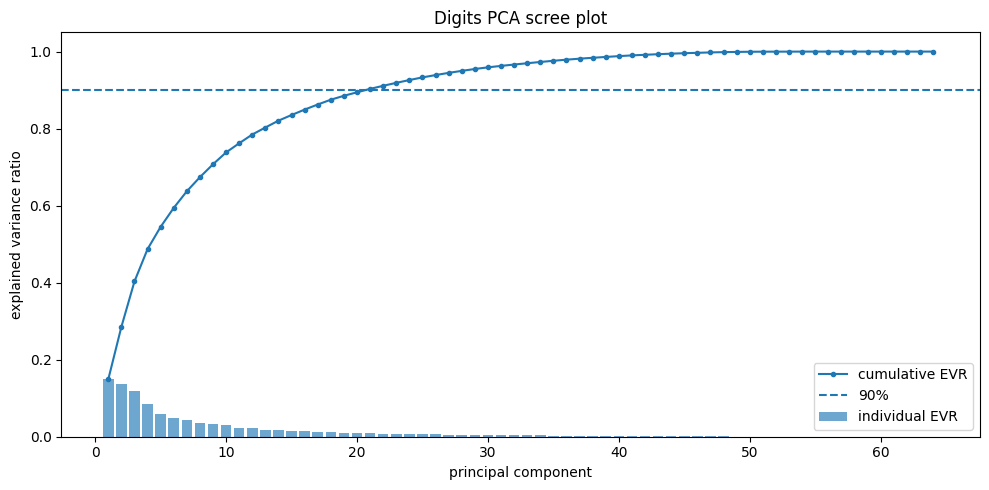

components for 90%: 21
components for 95%: 29


In [ ]:
# Starter
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
digits = load_digits()
X_digits, y_digits = digits.data, digits.target
print("wine:", X_wine.shape, "  digits:", X_digits.shape)

# TODO -- 2.1 build wine_feature_stats (index = wine.feature_names, columns = mean, std) and print it
# wine_feature_stats = pass

wine_means = X_wine.mean(axis=0)
wine_stds = X_wine.std(axis=0)

wine_feature_stats = pd.DataFrame(
    {
        "mean": wine_means,
        "std": wine_stds
    },
    index=wine.feature_names
)

print(wine_feature_stats)


def standardize_features(X):
    """Zero mean, unit variance, column by column. Given -- do not modify."""
    mu = X.mean(axis=0)
    sd = X.std(axis=0)                   # population std, matching the lecture
    sd = np.where(sd == 0.0, 1.0, sd)    # a constant feature would divide by zero
    return (X - mu) / sd


def pca_eigen(X, standardize=False):
    """Return (eigvals, eigvecs, evr), all sorted by descending eigenvalue.
    eigvecs[:, i] is the i-th principal component."""

    # TODO -- step 1: standardize if asked, then center
    # Xc = pass

    if standardize:
        X_use = standardize_features(X)
    else:
        X_use = X.astype(float)

    Xc = X_use - X_use.mean(axis=0)

    # TODO -- step 2: the covariance matrix, dividing by n (population convention)
    # Note: don't use np.cov's default, which divides by n-1. Pass bias=True, or write it out.
    # Sigma = pass

    n = Xc.shape[0]
    Sigma = (Xc.T @ Xc) / n

    # TODO -- step 3: eigenvalues and eigenvectors of Sigma, via np.linalg.eigh
    # eigvals, eigvecs = pass

    eigvals, eigvecs = np.linalg.eigh(Sigma)

    # TODO -- step 4: sort both by DESCENDING eigenvalue
    # eigvals, eigvecs = pass

    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Steps 5 and 6 (choosing k, and projecting) are the caller's job below.
    # TODO -- the explained variance ratio of each component
    # evr = pass

    evr = eigvals / eigvals.sum()

    return eigvals, eigvecs, evr


# TODO -- 2.2 validate pca_eigen against sklearn's PCA on the standardized wine data.
# Compare the explained variance ratios, and compare the PC1 loadings up to sign.
# Note: don't standardize here and again inside pca_eigen -- pick one place to do it.

X_wine_std = standardize_features(X_wine)

my_vals, my_vecs, my_evr = pca_eigen(
    X_wine_std,
    standardize=False
)

sk_pca = PCA()
sk_pca.fit(X_wine_std)

evr_difference = np.abs(
    my_evr - sk_pca.explained_variance_ratio_
)

pc1_difference = np.abs(
    np.abs(my_vecs[:, 0]) -
    np.abs(sk_pca.components_[0])
)

print("\n2.2 validation")
print("max EVR difference:", evr_difference.max())
print("max |PC1 loading| difference:", pc1_difference.max())


# TODO -- 2.3 the standardize-or-not contrast, plus the top-3 PC1 loadings for each
# evr_wine_raw = pass
# evr_wine_std = pass

raw_vals, raw_vecs, evr_wine_raw = pca_eigen(
    X_wine,
    standardize=False
)

std_vals, std_vecs, evr_wine_std = pca_eigen(
    X_wine,
    standardize=True
)

# Find the three largest loadings for raw wine.
raw_loading_sizes = np.abs(raw_vecs[:, 0])
raw_top = np.argsort(raw_loading_sizes)[::-1][:3]

print("\nRaw wine PCA")
print("PC1 EVR:", evr_wine_raw[0])
print("top 3 PC1 loadings:")

for i in raw_top:
    print(wine.feature_names[i], raw_vecs[i, 0])

# Do the same thing for standardized wine.
std_loading_sizes = np.abs(std_vecs[:, 0])
std_top = np.argsort(std_loading_sizes)[::-1][:3]

print("\nStandardized wine PCA")
print("PC1 EVR:", evr_wine_std[0])
print("top 3 PC1 loadings:")

for i in std_top:
    print(wine.feature_names[i], std_vecs[i, 0])


# TODO -- 2.4 the digits scree plot, then the two component counts
# evr_digits = pass
# n_components_90 = pass
# n_components_95 = pass

digit_vals, digit_vecs, evr_digits = pca_eigen(
    X_digits,
    standardize=False
)

cumulative_evr = np.cumsum(evr_digits)

n_components_90 = np.searchsorted(
    cumulative_evr,
    0.90
) + 1

n_components_95 = np.searchsorted(
    cumulative_evr,
    0.95
) + 1

components = np.arange(1, len(evr_digits) + 1)

plt.figure(figsize=(10, 5))

plt.bar(
    components,
    evr_digits,
    alpha=0.65,
    label="individual EVR"
)

plt.plot(
    components,
    cumulative_evr,
    marker=".",
    label="cumulative EVR"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90%"
)

plt.xlabel("principal component")
plt.ylabel("explained variance ratio")
plt.title("Digits PCA scree plot")
plt.legend()

plt.tight_layout()
plt.show()

print("components for 90%:", n_components_90)
print("components for 95%:", n_components_95)

*Your answers for 2.1, 2.3 and 2.4:*

**2.1** The wine features vary substantially in scale. For example, `proline` has a standard deviation of about 314, while several other features have standard deviations below 1. Since PCA is based on variance, applying it directly to the raw values would give larger-scale features disproportionate influence. For this reason, standardizing the wine data before PCA is more appropriate.

**2.3** There is a substantial difference between the raw and standardized PCA results. Without standardization, PC1 explains about 99.81% of the variance, and the three largest absolute loadings are `proline`, `magnesium`, and `alcalinity_of_ash`. In particular, `proline` dominates the first component. After standardization, PC1 explains about 36.20% of the variance, and the largest absolute loadings are `flavanoids`, `total_phenols`, and `od280/od315_of_diluted_wines`. This indicates that the raw PCA is largely reflecting differences in feature scale, while standardization allows the components to capture variation across the features more evenly.

**2.4** The digits scree plot shows that the earlier principal components account for most of the variance, after which the curve begins to level off. It takes 21 components to reach 90% of the explained variance and 29 components to reach 95%. I did not standardize the digit features because all 64 variables are pixel intensities measured on the same 0 to 16 scale. In addition, some border pixels have very little or no variation. Standardizing every pixel to unit variance could therefore give low-variance pixels more influence than is useful for this dataset.




### 3. K-means from scratch (8')
Implement Lloyd's algorithm yourself, check it against the library, and then use it to choose $K$.  
3.1 Complete `kmeans_fit()` below. It must return `(centroids, labels, inertia, n_iters)`.  
3.2 Validate. Run your `kmeans_fit(X_digits, K=10, seed=0)` and `KMeans(n_clusters=10, n_init=10, random_state=0)` on the same data. Store the two inertias as `my_inertia_k10` and `sklearn_inertia_k10`, report their relative difference, and report the adjusted Rand index between the two label vectors. Briefly comment: should these two numbers be identical, and if not, why not?  
3.3 Sweep $K$ from 2 to 15 on the digits data using *your* implementation. Build two dicts mapping $K$ to a number, `inertia_by_k` and `silhouette_by_k`, and plot them side by side in two subplots. Store the $K$ that maximizes the average silhouette as `best_k_silhouette`, and the $K$ you would read off the elbow as `best_k_elbow`.  
3.4 The digits data has 10 true classes. Compare `best_k_elbow`, `best_k_silhouette`, and 10, and comment on your observations. Explain why inertia alone could never have told you the answer.  

Following are some specifications that may be helpful:  
- Initialize each restart by sampling $K$ *distinct* rows of `X` as the starting centroids, using the `rng` that is already created for you so the run is reproducible.  
- Lloyd's algorithm converges to a *local* optimum that depends on the initialization, so `kmeans_fit` runs `n_init` independent restarts and keeps the one with the lowest inertia. This matters for 3.3: with a single restart, the inertia curve over $K$ is not even guaranteed to decrease, and the elbow becomes unreadable.  
- Assign each point with `np.argmin`, which breaks ties toward the lowest index. That keeps a seeded run reproducible across machines.  
- Stop a restart when no label changes, or when the largest centroid movement falls below `tol`, or after `max_iters` passes, whichever comes first.  
- Inertia is the *total* squared distance from every point to its own centroid, matching the definition in lecture. Report the total, not the mean.  
- Note: don't call `sklearn.cluster.KMeans` anywhere inside `kmeans_fit`, and don't call it inside the 3.3 sweep either. The point of this part is your own loop.  

my inertia: 1165160.3788412327
sklearn inertia: 1165188.890449231
relative difference: 2.446951582870921e-05
ARI between labelings: 0.9936761644557203


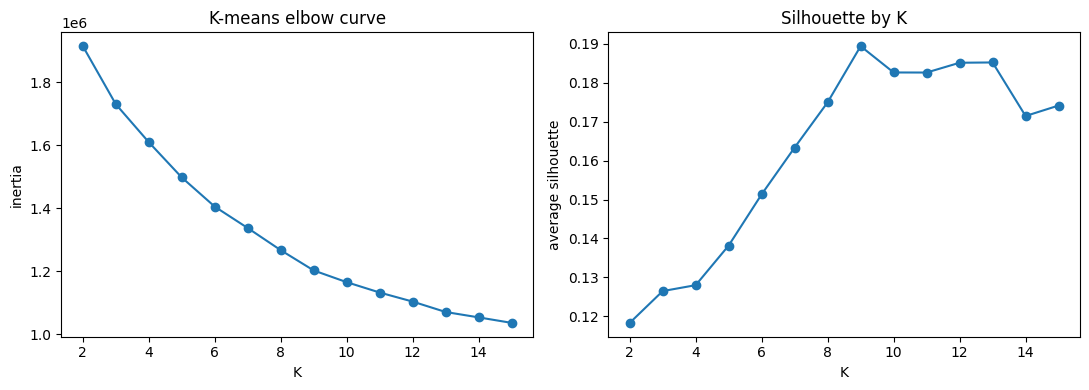

best_k_elbow: 10
best_k_silhouette: 9


In [ ]:
# Starter
def pairwise_sq_dists(X, C):
    """Squared Euclidean distances between every row of X (n, p) and every row
    of C (K, p). Returns an (n, K) array. Given -- do not modify."""
    return ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=-1)


def _kmeans_one_run(X, K, rng, max_iters, tol):
    """One restart of Lloyd's algorithm. Returns (centroids, labels, inertia, n_iters)."""
    n = X.shape[0]
    centroids = X[rng.choice(n, size=K, replace=False)].astype(float).copy()
    labels = np.full(n, -1)

    for it in range(max_iters):
        # TODO -- assign step: the squared distances, then the nearest centroid per point
        # d2 = pass
        # new_labels = pass

        d2 = pairwise_sq_dists(X, centroids)
        new_labels = np.argmin(d2, axis=1)

        # TODO -- update step: move every centroid to the mean of its members.
        # The empty-cluster branch is given, because np.mean of an empty slice is nan.
        new_centroids = centroids.copy()

        for k in range(K):
            members = X[new_labels == k]

            if len(members) == 0:
                new_centroids[k] = X[np.argmax(d2.min(axis=1))]  # worst-served point
            else:
                # new_centroids[k] = pass  # TODO
                new_centroids[k] = members.mean(axis=0)

        shift = np.abs(new_centroids - centroids).max()
        converged = (new_labels == labels).all() or shift < tol
        centroids, labels = new_centroids, new_labels

        if converged:
            break

    # TODO -- inertia: the total squared distance from each point to its OWN centroid
    # inertia = pass

    assigned_centroids = centroids[labels]
    squared_distances = (X - assigned_centroids) ** 2
    inertia = float(squared_distances.sum())

    return centroids, labels, inertia, it + 1


def kmeans_fit(X, K, seed=0, n_init=10, max_iters=100, tol=1e-6):
    """Run n_init restarts of Lloyd's algorithm and keep the lowest-inertia one."""
    rng = np.random.default_rng(seed)
    best = None

    for _ in range(n_init):
        # TODO -- one restart, then keep it if its inertia beats the best so far
        # pass

        result = _kmeans_one_run(
            X,
            K,
            rng,
            max_iters,
            tol
        )

        if best is None or result[2] < best[2]:
            best = result

    return best


# TODO -- 3.2 validate against sklearn, and print the relative difference and the ARI
# my_inertia_k10 = pass
# sklearn_inertia_k10 = pass

my_centroids, my_labels, my_inertia_k10, my_iters = kmeans_fit(
    X_digits,
    K=10,
    seed=0
)

sk_model = KMeans(
    n_clusters=10,
    n_init=10,
    random_state=0
)

sk_model.fit(X_digits)

sklearn_inertia_k10 = float(sk_model.inertia_)

difference = abs(my_inertia_k10 - sklearn_inertia_k10)
relative_difference = difference / sklearn_inertia_k10

ari_vs_sklearn = adjusted_rand_score(
    my_labels,
    sk_model.labels_
)

print("my inertia:", my_inertia_k10)
print("sklearn inertia:", sklearn_inertia_k10)
print("relative difference:", relative_difference)
print("ARI between labelings:", ari_vs_sklearn)


# TODO -- 3.3 sweep K from 2 to 15, fill both dicts, then plot two subplots
# inertia_by_k = pass
# silhouette_by_k = pass
best_k_elbow = None
best_k_silhouette = None

inertia_by_k = {}
silhouette_by_k = {}

for K in range(2, 16):
    centroids, labels, inertia, n_iters = kmeans_fit(
        X_digits,
        K=K,
        seed=0
    )

    inertia_by_k[K] = inertia
    silhouette_by_k[K] = float(
        silhouette_score(X_digits, labels)
    )

# Pick the K with the highest silhouette score.
best_k_silhouette = max(
    silhouette_by_k,
    key=silhouette_by_k.get
)

# From the plot, the elbow looks like it is around K = 10.
best_k_elbow = 10

ks = list(range(2, 16))

inertia_values = []
silhouette_values = []

for K in ks:
    inertia_values.append(inertia_by_k[K])
    silhouette_values.append(silhouette_by_k[K])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    ks,
    inertia_values,
    marker="o"
)

axes[0].set_xlabel("K")
axes[0].set_ylabel("inertia")
axes[0].set_title("K-means elbow curve")

axes[1].plot(
    ks,
    silhouette_values,
    marker="o"
)

axes[1].set_xlabel("K")
axes[1].set_ylabel("average silhouette")
axes[1].set_title("Silhouette by K")

plt.tight_layout()
plt.show()

print("best_k_elbow:", best_k_elbow)
print("best_k_silhouette:", best_k_silhouette)

*Your answers for 3.2 and 3.4:*

**3.2** My implementation gives inertia about
- 1,165,160.38,
while scikit-learn gives about
- 1,165,188.89.
- The relative difference is only about **0.0000245** (around 0.0024%), and the ARI between the two cluster labelings is about **0.994**. I would not expect the results to be exactly identical because both methods can land in different local optima depending on how the initial centroids are sampled, even with the same numerical seed.

**3.4** I read the elbow as roughly
- K = 10
, while the maximum silhouette occurs at
- K = 9.
- The true number of digit classes is 10, so the elbow happens to agree with the known class count, but the silhouette criterion prefers one fewer cluster. That makes sense because some digit classes overlap in pixel space and a geometrically compact clustering is not required to match the semantic digit labels. Inertia by itself cannot tell me the correct K because it decreases as K increases, even if I keep splitting meaningful clusters into smaller pieces.


### 4. Where K-means fails (7')
K-means is not wrong, it is *assuming* something. Here we build two datasets that violate its assumptions in two different ways, and compare it against hierarchical clustering and DBSCAN.  
4.1 Generate the two datasets with the exact calls given in the starter, and plot both, coloured by their true labels. `moons` is two interleaved crescents. `blobs` is three spherical clusters whose standard deviations differ by a factor of five.  
4.2 On each dataset, run five methods: K-means with the correct $K$; agglomerative clustering with `single`, `complete`, and `average` linkage; and DBSCAN. Fill a DataFrame named `comparison_df` with exactly the columns `["dataset", "method", "n_clusters_found", "ari", "silhouette"]` and print it. Plot the ten clusterings in a 2 x 5 grid using the given `plot_clusters()` helper.  
4.3 DBSCAN's answer depends entirely on $\varepsilon$. For the moons dataset, sweep $\varepsilon$ over the grid `EPS_GRID` given in the starter at `min_samples=5`, and fill a DataFrame named `dbscan_grid_df` with exactly the columns `["eps", "n_clusters_found", "noise_frac", "ari"]`. Report the $\varepsilon$ you chose and how you chose it.  
4.4 Write your analysis. Address all four:  
- Which methods recover the crescents, and which do not? Explain *geometrically* why K-means cannot, referring to the shape of the region each centroid owns.  
- Single and complete linkage disagree sharply on `moons`, and they disagree in the opposite direction on `blobs`. Connect both to your answer in 1.3(e).  
- On `moons`, compare the silhouette score of the *true* labels against the silhouette score of the K-means labels. Which is higher? What does that tell you about using an internal metric to choose between algorithms?  
- On the unequal-variance `blobs`, DBSCAN has a harder time than it did on `moons`. Explain why a single global $\varepsilon$ is the problem.  

Following are some specifications that may be helpful:  
- Note: don't use the true labels to pick $\varepsilon$ or $K$. Choose them from the data, then report the ARI afterwards. The ARI column exists so *you* can see how well the label-free choice did, and that is only an honest exercise if you make the choice first.  
- DBSCAN labels noise as `-1`, which is not a cluster. Both given helpers already account for that.  

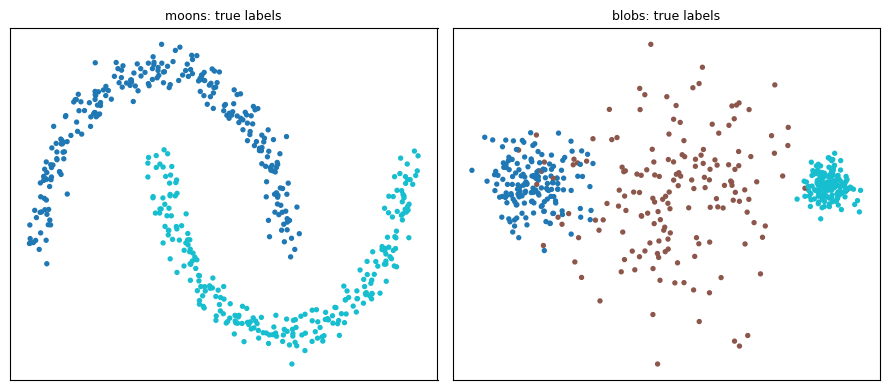

DBSCAN sweep on moons:
    eps  n_clusters_found  noise_frac       ari
0  0.10                 2       0.016  0.968238
1  0.15                 2       0.002  0.996008
2  0.20                 2       0.000  1.000000
3  0.25                 2       0.000  1.000000
4  0.30                 2       0.000  1.000000
5  0.40                 1       0.000  0.000000
6  0.60                 1       0.000  0.000000

Method comparison:
  dataset          method  n_clusters_found           ari  silhouette
0   moons          kmeans                 2  2.525184e-01    0.488666
1   moons    agglo-single                 2  1.000000e+00    0.329892
2   moons  agglo-complete                 2  4.451214e-01    0.473745
3   moons   agglo-average                 2  4.452348e-01    0.443361
4   moons          dbscan                 2  1.000000e+00    0.329892
5   blobs          kmeans                 3  7.974977e-01    0.624404
6   blobs    agglo-single                 3  9.638786e-08    0.119344
7   blobs  ag

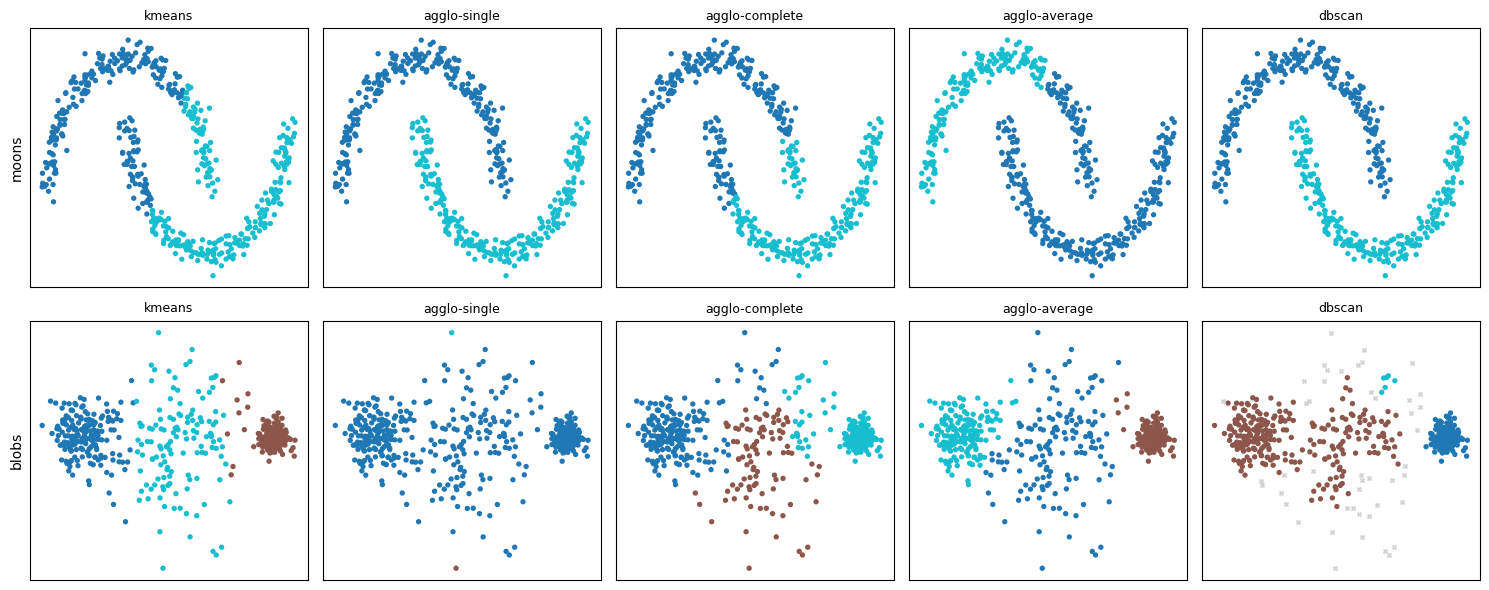


True-label silhouette on moons: 0.3298922727595921
K-means silhouette on moons: 0.48866587971028913


In [ ]:
# Starter
X_moons, y_moons = make_moons(n_samples=500, noise=0.06, random_state=0)
X_blobs, y_blobs = make_blobs(n_samples=500,
                             centers=[[-6.0, 0.0], [0.0, 0.0], [6.0, 0.0]],
                             cluster_std=[1.0, 2.5, 0.5], random_state=0)
DATASETS = {"moons": (X_moons, y_moons, 2), "blobs": (X_blobs, y_blobs, 3)}
EPS_GRID = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.60]
METHODS = ["kmeans", "agglo-single", "agglo-complete", "agglo-average", "dbscan"]


def plot_clusters(X, labels, title, ax):
    """Scatter X coloured by labels; DBSCAN noise (-1) is drawn as a grey x.
    Given -- do not modify."""
    noise = labels == -1
    ax.scatter(X[~noise, 0], X[~noise, 1], c=labels[~noise], s=8, cmap="tab10")
    ax.scatter(X[noise, 0], X[noise, 1], c="lightgray", s=8, marker="x")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])


def n_clusters_found(labels):
    """How many real clusters, excluding DBSCAN's noise label. Given."""
    return len(set(np.asarray(labels).tolist()) - {-1})


def safe_silhouette(X, labels):
    """Average silhouette over the non-noise points. Returns nan when fewer than
    two clusters survive -- silhouette_score raises on a single-cluster labeling,
    and DBSCAN produces one easily. Given -- do not modify."""
    labels = np.asarray(labels)
    mask = labels != -1
    if len(set(labels[mask].tolist())) < 2 or mask.sum() < 3:
        return float("nan")
    return float(silhouette_score(X[mask], labels[mask]))


# TODO -- 4.1 plot both datasets coloured by their true labels

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

plot_clusters(
    X_moons,
    y_moons,
    "moons: true labels",
    axes[0]
)

plot_clusters(
    X_blobs,
    y_blobs,
    "blobs: true labels",
    axes[1]
)

plt.tight_layout()
plt.show()


# TODO -- 4.3 the eps sweep on moons (do this before 4.2, so it informs your choice)
# dbscan_grid_df = pass

dbscan_rows = []

for eps in EPS_GRID:
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X_moons)

    dbscan_rows.append({
        "eps": eps,
        "n_clusters_found": n_clusters_found(labels),
        "noise_frac": float(np.mean(labels == -1)),
        "ari": float(adjusted_rand_score(y_moons, labels))
    })

dbscan_grid_df = pd.DataFrame(
    dbscan_rows,
    columns=[
        "eps",
        "n_clusters_found",
        "noise_frac",
        "ari"
    ]
)

print("DBSCAN sweep on moons:")
print(dbscan_grid_df)


# TODO -- 4.2 pick an eps per dataset, run the five methods on each, fill comparison_df,
# and plot the 2x5 grid. METHODS above fixes the column order for the grid.
DBSCAN_PARAMS = {"moons": dict(eps=None, min_samples=5),
                 "blobs": dict(eps=None, min_samples=5)}
# comparison_df = pass

# I chose 0.20 for moons because the sweep gives 2 clusters
# with no noise and stays stable around this value.
DBSCAN_PARAMS["moons"]["eps"] = 0.20

# 0.80 worked reasonably well for the different-density blobs.
DBSCAN_PARAMS["blobs"]["eps"] = 0.80


comparison_rows = []
all_labels = {}

for dataset_name in DATASETS:
    X, y_true, K = DATASETS[dataset_name]

    # K-means
    kmeans_labels = KMeans(
        n_clusters=K,
        n_init=10,
        random_state=0
    ).fit_predict(X)

    # Single linkage
    single_labels = AgglomerativeClustering(
        n_clusters=K,
        linkage="single"
    ).fit_predict(X)

    # Complete linkage
    complete_labels = AgglomerativeClustering(
        n_clusters=K,
        linkage="complete"
    ).fit_predict(X)

    # Average linkage
    average_labels = AgglomerativeClustering(
        n_clusters=K,
        linkage="average"
    ).fit_predict(X)

    # DBSCAN
    params = DBSCAN_PARAMS[dataset_name]

    dbscan_labels = DBSCAN(
        eps=params["eps"],
        min_samples=params["min_samples"]
    ).fit_predict(X)

    labels_for_methods = {
        "kmeans": kmeans_labels,
        "agglo-single": single_labels,
        "agglo-complete": complete_labels,
        "agglo-average": average_labels,
        "dbscan": dbscan_labels
    }

    for method in METHODS:
        labels = labels_for_methods[method]

        all_labels[(dataset_name, method)] = labels

        comparison_rows.append({
            "dataset": dataset_name,
            "method": method,
            "n_clusters_found": n_clusters_found(labels),
            "ari": float(adjusted_rand_score(y_true, labels)),
            "silhouette": safe_silhouette(X, labels)
        })


comparison_df = pd.DataFrame(
    comparison_rows,
    columns=[
        "dataset",
        "method",
        "n_clusters_found",
        "ari",
        "silhouette"
    ]
)

print("\nMethod comparison:")
print(comparison_df)


# Plot the 2x5 grid.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

dataset_order = ["moons", "blobs"]

for row_number in range(len(dataset_order)):
    dataset_name = dataset_order[row_number]
    X = DATASETS[dataset_name][0]

    for col_number in range(len(METHODS)):
        method = METHODS[col_number]
        labels = all_labels[(dataset_name, method)]

        plot_clusters(
            X,
            labels,
            method,
            axes[row_number, col_number]
        )

        if col_number == 0:
            axes[row_number, col_number].set_ylabel(dataset_name)

plt.tight_layout()
plt.show()


# Compare K-means silhouette with the true moon grouping.
true_moon_silhouette = silhouette_score(
    X_moons,
    y_moons
)

moon_kmeans_row = comparison_df[
    (comparison_df["dataset"] == "moons")
    & (comparison_df["method"] == "kmeans")
]

kmeans_moon_silhouette = moon_kmeans_row["silhouette"].iloc[0]

print("\nTrue-label silhouette on moons:", true_moon_silhouette)
print("K-means silhouette on moons:", kmeans_moon_silhouette)

4.3

I chose $\varepsilon = 0.20$ for the moons data. Looking at the epsilon sweep without using ARI to make the decision, 0.20 is the first value in a stable range where DBSCAN finds two clusters and leaves no points as noise. By $\varepsilon = 0.40$, the two clusters merge into one, so 0.20 is far enough below that transition while still giving a clean two-cluster result.

4.4

On the moons data, single linkage and DBSCAN are able to recover the two curved clusters, while K-means does not. Complete and average linkage also divide the moons in ways that do not follow the original shapes very well. K-means assigns each point to its nearest centroid, which works best when clusters are relatively compact around a center. The two interleaved crescents do not fit that geometry well.

Single linkage performs well on the moons because it can connect nearby points along a curved shape. However, that same chaining behavior causes problems on the unequal-variance blobs. A small number of nearby points can create a connection between groups that would otherwise be separate. Complete linkage is less sensitive to this chaining effect, which makes it less successful on the crescents but more reasonable on the blob data. This is consistent with the behavior seen earlier in 1.3.

Another interesting result is that the true moon labels have a silhouette score of about 0.330, while K-means has a higher silhouette score of about 0.489 even though its ARI is only about 0.253. This shows that a higher internal clustering score does not necessarily mean the clusters match the meaningful structure of the data. Silhouette favors clusters that are compact and well separated, so in this case it prefers the more compact K-means partition even though it does not recover the two crescents.

DBSCAN is also more difficult to tune on the blob data because the three clusters have different densities. A single value of $\varepsilon$ that is large enough to connect the more spread-out middle cluster may also be large enough to start merging the denser clusters. On the other hand, using a smaller value can preserve the dense groups but cause points in the diffuse cluster to be labeled as noise or split into smaller groups.

### 5. Reduce, then cluster, and evaluate (10')
This is the pipeline from the lecture, end to end, on the digits dataset. The true labels `y_digits` are **withheld from every clustering call** and used only for evaluation afterwards. Treat that as a rule, not a suggestion.  
5.1 Complete `reduce_then_cluster()` below: reduce `X` to `n_components` with PCA, then cluster the reduced representation with K-means. `n_components=None` means skip the reduction and cluster the raw 64 features.  
5.2 For `n_components` in `N_COMPONENTS_GRID` with $K = 10$ and `seed=0`, build a DataFrame named `eval_df` with exactly the columns `["n_components", "ari", "nmi", "silhouette", "davies_bouldin"]`, and print it. Store the `n_components` with the highest ARI as `best_n_components`. Plot ARI and average silhouette against `n_components` on the same axes with two y-scales.  
5.3 Stability. Fix `n_components = best_n_components` and $K = 10$, and repeat the clustering five times with the seeds in `SEEDS`. Record the five ARI-against-truth numbers in a list named `stability_ari`, and report their mean and standard deviation. Then compute the adjusted Rand index between every *pair* of those five clusterings -- ten pairs, no labels involved -- and store the mean as `stability_pairwise_ari`.  
5.4 Visualize the ten K-means centroids from your best pipeline as 8x8 images, by mapping them back into pixel space with the fitted PCA's `inverse_transform`. Plot them in a 2 x 5 grid.  
5.5 Write your analysis. Address all four:  
- Does reducing before clustering help? At which `n_components` does ARI peak, and what is happening at the two ends of the range?  
- Average silhouette and ARI do not peak at the same `n_components`. Describe the disagreement and explain it. Which of the two would you have had access to if the labels genuinely did not exist?  
- What do `stability_ari` and `stability_pairwise_ari` tell you that a single run cannot? Which of the two could you still compute with no labels at all?  
- Look at your ten centroid images. Name one digit that clearly got its own centroid and one pair of digits that appear to have been merged or split, and say in one sentence why you would not report these ten clusters to someone as "the ten digits".  

Following are some specifications that may be helpful:  
- Note: don't standardize the digits features here. All 64 are pixel intensities on the same 0-16 scale, and 3 border pixels are constant zero, so dividing by their standard deviation is either a division by zero or an amplification of pure noise.  
- Fit the PCA on `X` and cluster the transformed array. Do not refit the PCA once per seed in 5.3; only the K-means seed changes there.  
- Cluster IDs are arbitrary names, so never compare them to class IDs with accuracy -- a relabeled clustering is the same clustering. The adjusted Rand index and normalized mutual information are invariant to relabeling, which is exactly why we use them.  
- Compute `silhouette` and `davies_bouldin` in the space you clustered in, and say which space that was. They are not comparable across different `n_components` for free; mention this in your analysis.  
- Lower Davies-Bouldin is better. Higher silhouette, ARI, and NMI are better.  

   n_components       ari       nmi  silhouette  davies_bouldin
0           NaN  0.665728  0.742465    0.182536        1.924846
1           2.0  0.392682  0.526944    0.393748        0.797988
2           5.0  0.554009  0.656520    0.340083        1.070146
3          10.0  0.651706  0.726864    0.263931        1.452758
4          20.0  0.667917  0.743096    0.212678        1.736961
5          40.0  0.659950  0.737918    0.185585        1.904929
best_n_components: 20


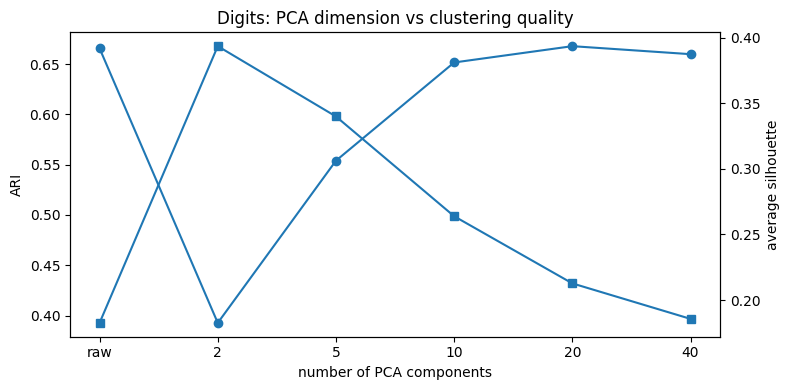

stability_ari: [0.6636965949982628, 0.6694420938936954, 0.6629019303949295, 0.6631633288546032, 0.6695538387756078]
stability ARI mean: 0.6657515573834197
stability ARI std: 0.0030698395663089203
mean pairwise clustering ARI: 0.9811673852972476


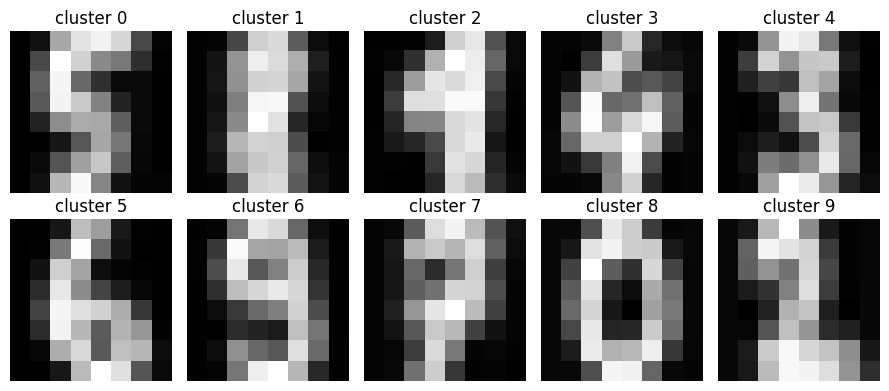

In [ ]:
# Starter
N_COMPONENTS_GRID = [None, 2, 5, 10, 20, 40]
SEEDS = [1, 2, 3, 31, 42]


def reduce_then_cluster(X, n_components, K, seed):
    """Return (labels, X_reduced, pca). pca is None when n_components is None."""
    if n_components is None:
        X_reduced, pca = X, None
    else:
        # TODO -- fit a PCA with n_components on X, then transform X
        # pca = pass
        # X_reduced = pass

        pca = PCA(n_components=n_components)
        X_reduced = pca.fit_transform(X)

    # TODO -- K-means on X_reduced. Use n_init=10 and random_state=seed.
    # labels = pass

    model = KMeans(
        n_clusters=K,
        n_init=10,
        random_state=seed
    )

    labels = model.fit_predict(X_reduced)

    return labels, X_reduced, pca


# TODO -- 5.2 build eval_df over N_COMPONENTS_GRID, then best_n_components, then the two-axis plot
# eval_df = pass
best_n_components = None

evaluation_rows = []

for n_components in N_COMPONENTS_GRID:
    labels, X_reduced, pca = reduce_then_cluster(
        X_digits,
        n_components,
        K=10,
        seed=0
    )

    ari = adjusted_rand_score(
        y_digits,
        labels
    )

    nmi = normalized_mutual_info_score(
        y_digits,
        labels
    )

    silhouette = silhouette_score(
        X_reduced,
        labels
    )

    db_score = davies_bouldin_score(
        X_reduced,
        labels
    )

    evaluation_rows.append({
        "n_components": n_components,
        "ari": float(ari),
        "nmi": float(nmi),
        "silhouette": float(silhouette),
        "davies_bouldin": float(db_score)
    })


eval_df = pd.DataFrame(
    evaluation_rows,
    columns=[
        "n_components",
        "ari",
        "nmi",
        "silhouette",
        "davies_bouldin"
    ]
)

# Use ARI to choose the best PCA dimension.
best_index = eval_df["ari"].idxmax()
best_n_components = eval_df.loc[
    best_index,
    "n_components"
]

# None becomes NaN inside the DataFrame, so change it back if needed.
if pd.isna(best_n_components):
    best_n_components = None
else:
    best_n_components = int(best_n_components)

print(eval_df)
print("best_n_components:", best_n_components)


# Plot ARI and silhouette together.
positions = np.arange(len(N_COMPONENTS_GRID))

x_labels = []

for value in N_COMPONENTS_GRID:
    if value is None:
        x_labels.append("raw")
    else:
        x_labels.append(str(value))


fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(
    positions,
    eval_df["ari"],
    marker="o",
    label="ARI"
)

ax2.plot(
    positions,
    eval_df["silhouette"],
    marker="s",
    label="silhouette"
)

ax1.set_xticks(positions)
ax1.set_xticklabels(x_labels)

ax1.set_xlabel("number of PCA components")
ax1.set_ylabel("ARI")
ax2.set_ylabel("average silhouette")

ax1.set_title("Digits: PCA dimension vs clustering quality")

plt.tight_layout()
plt.show()


# TODO -- 5.3 stability across the five SEEDS, against truth and pairwise
# stability_ari = pass
# stability_pairwise_ari = pass

# Fit the PCA once so only the K-means seed changes below.
if best_n_components is None:
    X_best = X_digits
    pca_best = None
else:
    pca_best = PCA(
        n_components=best_n_components
    )

    X_best = pca_best.fit_transform(X_digits)


stability_labels = []
stability_ari = []

for seed in SEEDS:
    model = KMeans(
        n_clusters=10,
        n_init=10,
        random_state=seed
    )

    labels = model.fit_predict(X_best)

    stability_labels.append(labels)

    ari = adjusted_rand_score(
        y_digits,
        labels
    )

    stability_ari.append(float(ari))


# Compare each clustering to every other clustering.
pairwise_aris = []

for i in range(len(stability_labels)):
    for j in range(i + 1, len(stability_labels)):
        score = adjusted_rand_score(
            stability_labels[i],
            stability_labels[j]
        )

        pairwise_aris.append(score)


stability_pairwise_ari = float(
    np.mean(pairwise_aris)
)

print("stability_ari:", stability_ari)
print("stability ARI mean:", np.mean(stability_ari))
print("stability ARI std:", np.std(stability_ari))
print("mean pairwise clustering ARI:", stability_pairwise_ari)


# TODO -- 5.4 the ten centroids as 8x8 images, via pca.inverse_transform

best_kmeans = KMeans(
    n_clusters=10,
    n_init=10,
    random_state=0
)

best_kmeans.fit(X_best)

centers = best_kmeans.cluster_centers_

# If PCA was used, move the centroids back to the original 64-pixel space.
if pca_best is None:
    centroid_pixels = centers
else:
    centroid_pixels = pca_best.inverse_transform(centers)


fig, axes = plt.subplots(2, 5, figsize=(9, 4))

for k in range(10):
    ax = axes.flat[k]

    image = centroid_pixels[k].reshape(8, 8)

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title("cluster " + str(k))
    ax.axis("off")

plt.tight_layout()
plt.show()

5.5

Reducing the data before clustering helps slightly, but only when enough components are retained. The highest ARI occurs at 20 components, where it is about 0.668, compared with about 0.666 when clustering the original 64-dimensional data. At 2 components, too much information has been removed and the ARI drops to about 0.393. At 40 components, the result is already close to the raw-data case, so PCA is doing less dimensionality reduction and less filtering of lower-variance information.

ARI and silhouette do not select the same number of components. The silhouette score is highest at 2 components, at about 0.394, while ARI is highest at 20 components. In two dimensions, K-means can form clusters that are compact and well separated even if those clusters do not correspond closely to the actual digit classes. If the true labels were unavailable, I could compute silhouette but not ARI, so the higher silhouette score would not be enough to conclude that the 2-component representation gives the most meaningful clustering. The silhouette and Davies-Bouldin scores are also calculated in the same space used for clustering, so scores from different numbers of PCA components are

-----
-----
-----